---
tags: [tutorial, resource-estimation]
---

# リソース推定

量子カーネルを実機で実行する前に、必要なリソース（量子ビット数、ゲート数等）を把握しておきたい場合や、そもそも定義した量子カーネルを実行するために必要なリソースを知りたい場合があります。Qamomileの`estimate_resources()`は**量子カーネルを実行せずに**リソース推定が可能です。具体的な（パラメータ固定の）量子カーネルにも、シンボリック（パラメータ付き）な量子カーネルにも対応しています。

この章では以下を扱います：

- 固定量子カーネルの基本的なリソース推定
- パラメータ付き量子カーネルのシンボリックなリソース推定
- `ResourceEstimate`フィールドリファレンス
- `.substitute()`によるスケーリング分析

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install qamomile

In [2]:
import qamomile.circuit as qmc

## 固定量子カーネルのリソース推定

パラメータを持たない量子カーネルに対しては、`estimate_resources()`は具体的な数値を返します。

In [3]:
@qmc.qkernel
def fixed_circuit() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(3, name="q")

    q[0] = qmc.h(q[0])
    q[0], q[1] = qmc.cx(q[0], q[1])
    q[1], q[2] = qmc.cx(q[1], q[2])

    return qmc.measure(q)

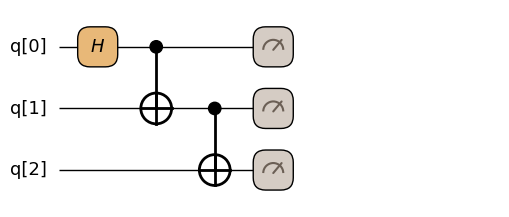

In [4]:
fixed_circuit.draw()

In [5]:
est = fixed_circuit.estimate_resources()
print("qubits:", est.qubits)
print("total gates:", est.gates.total)
print("single-qubit gates:", est.gates.single_qubit)
print("two-qubit gates:", est.gates.two_qubit)

qubits: 3
total gates: 3
single-qubit gates: 1
two-qubit gates: 2


## シンボリックなリソース推定

量子カーネルに未バインドのパラメータ（例：`n: qmc.UInt`）がある場合、`estimate_resources()`は**SymPy式**を返します。特定の値を選ばなくてもコストのスケーリングが分かります。

In [6]:
@qmc.qkernel
def scalable_circuit(n: qmc.UInt, theta: qmc.Float) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")

    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
        q[i] = qmc.ry(q[i], theta)

    for i in qmc.range(n - 1):
        q[i], q[i + 1] = qmc.cx(q[i], q[i + 1])

    return qmc.measure(q)

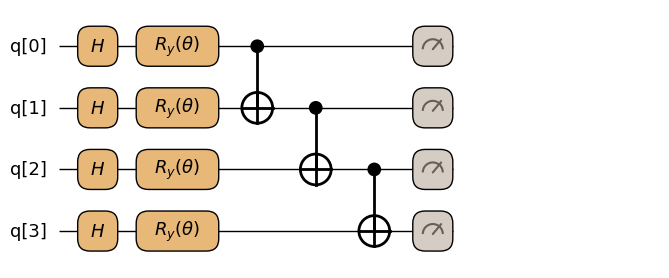

In [7]:
scalable_circuit.draw(n=4, fold_loops=False)

In [8]:
est = scalable_circuit.estimate_resources()
print("qubits:", est.qubits)
print("total gates:", est.gates.total)
print("single-qubit gates:", est.gates.single_qubit)
print("two-qubit gates:", est.gates.two_qubit)
print("rotation gates:", est.gates.rotation_gates)
print("parameters:", est.parameters)

qubits: n
total gates: 3*n - 1
single-qubit gates: 2*n
two-qubit gates: n - 1
rotation gates: n
parameters: {'n': n}


出力には、量子ビット数を表す`n`や総ゲート数を表す`3*n - 1`のようなSymPy式が含まれます。これらは近似ではなく厳密な値です。

## `ResourceEstimate`フィールドリファレンス

| フィールド | 説明 |
|-------|------------|
| `est.qubits` | 論理量子ビット数 |
| `est.gates.total` | 総ゲート数 |
| `est.gates.single_qubit` | 単一量子ビットゲート数 |
| `est.gates.two_qubit` | 2量子ビットゲート数 |
| `est.gates.multi_qubit` | 多量子ビットゲート数（3量子ビット以上） |
| `est.gates.t_gates` | Tゲート数 |
| `est.gates.clifford_gates` | Cliffordゲート数 |
| `est.gates.rotation_gates` | 回転ゲート数 |
| `est.gates.oracle_calls` | オラクル呼び出し回数（名前別の辞書） |
| `est.parameters` | シンボル名からSymPyシンボルへの辞書 |

すべてのフィールドはSymPy式です。固定量子カーネルの場合は通常の整数に評価されます。

## `.substitute()`によるスケーリング分析

シンボリック式は*数式*を示してくれますが、特定のサイズでの具体的な数値も確認したい場合`.substitute()`で評価できます：

In [9]:
for n_val in [4, 8, 16, 32]:
    c = est.substitute(n=n_val)
    print(
        f"n={n_val:2d}: {int(c.gates.total):>3} gates total, {int(c.gates.two_qubit):>2} two-qubit"
    )

n= 4:  11 gates total,  3 two-qubit
n= 8:  23 gates total,  7 two-qubit
n=16:  47 gates total, 15 two-qubit
n=32:  95 gates total, 31 two-qubit


## まとめ

- `estimate_resources()`は実行せずに量子ビット数とゲートコストを算出します。
- パラメータ付き量子カーネルでは、結果は厳密なスケーリングを示すSymPy式になります。
- `.substitute(n=...)`で特定のサイズに代入し、実行可能性を確認できます。

**次へ**：[実行モデル](04_execution_models.ipynb) — `sample()`と`run()`、オブザーバブル、ビット順序について。